# Final Prediction
## Import data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc
from sklearn.impute import SimpleImputer


In [2]:
df = pd.read_csv('./data/final_project.csv',header=0)

In [3]:
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x41,x42,x43,x44,x45,x46,x47,x48,x49,y
0,-0.166563,-3.961588,4.621113,2.481908,-1.800135,0.804684,6.718751,-14.789997,-1.040673,-4.204950,...,-1.497117,5.414063,-2.325655,1.674827,-0.264332,60.781427,-7.689696,0.151589,-8.040166,0
1,-0.149894,-0.585676,27.839856,4.152333,6.426802,-2.426943,40.477058,-6.725709,0.896421,0.330165,...,36.292790,4.490915,0.762561,6.526662,1.007927,15.805696,-4.896678,-0.320283,16.719974,0
2,-0.321707,-1.429819,12.251561,6.586874,-5.304647,-11.311090,17.812850,11.060572,5.325880,-2.632984,...,-0.368491,9.088864,-0.689886,-2.731118,0.754200,30.856417,-7.428573,-2.090804,-7.869421,0
3,-0.245594,5.076677,-24.149632,3.637307,6.505811,2.290224,-35.111751,-18.913592,-0.337041,-5.568076,...,15.691546,-7.467775,2.940789,-6.424112,0.419776,-72.424569,5.361375,1.806070,-7.670847,0
4,-0.273366,0.306326,-11.352593,1.676758,2.928441,-0.616824,-16.505817,27.532281,1.199715,-4.309105,...,-13.911297,-5.229937,1.783928,3.957801,-0.096988,-14.085435,-0.208351,-0.894942,15.724742,1


In [4]:
df.shape

(160000, 51)

In [5]:
print("Numeric columns:", df.select_dtypes(include='number').columns.tolist())
print("Categorical columns:", df.select_dtypes(include=['object', 'category']).columns.tolist())


Numeric columns: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x25', 'x26', 'x27', 'x28', 'x31', 'x33', 'x34', 'x35', 'x36', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'y']
Categorical columns: ['x24', 'x29', 'x30', 'x32', 'x37']


In [6]:
df_num = df.select_dtypes(include='number')
df_cat = df.select_dtypes(include='object')

df_num.head()


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x41,x42,x43,x44,x45,x46,x47,x48,x49,y
0,-0.166563,-3.961588,4.621113,2.481908,-1.800135,0.804684,6.718751,-14.789997,-1.040673,-4.204950,...,-1.497117,5.414063,-2.325655,1.674827,-0.264332,60.781427,-7.689696,0.151589,-8.040166,0
1,-0.149894,-0.585676,27.839856,4.152333,6.426802,-2.426943,40.477058,-6.725709,0.896421,0.330165,...,36.292790,4.490915,0.762561,6.526662,1.007927,15.805696,-4.896678,-0.320283,16.719974,0
2,-0.321707,-1.429819,12.251561,6.586874,-5.304647,-11.311090,17.812850,11.060572,5.325880,-2.632984,...,-0.368491,9.088864,-0.689886,-2.731118,0.754200,30.856417,-7.428573,-2.090804,-7.869421,0
3,-0.245594,5.076677,-24.149632,3.637307,6.505811,2.290224,-35.111751,-18.913592,-0.337041,-5.568076,...,15.691546,-7.467775,2.940789,-6.424112,0.419776,-72.424569,5.361375,1.806070,-7.670847,0
4,-0.273366,0.306326,-11.352593,1.676758,2.928441,-0.616824,-16.505817,27.532281,1.199715,-4.309105,...,-13.911297,-5.229937,1.783928,3.957801,-0.096988,-14.085435,-0.208351,-0.894942,15.724742,1


In [7]:
df_cat.head()

,x24,x29,x30,x32,x37
0,euorpe,July,tuesday,0.0%,$1313.96
1,asia,Aug,wednesday,-0.02%,$1962.78
2,asia,July,wednesday,-0.01%,$430.47
3,asia,July,wednesday,0.01%,$-2366.29
4,asia,July,tuesday,0.01%,$-620.66


In [8]:
df.x32.value_counts()

x32
0.01%     40767
-0.01%    34094
0.0%      33923
-0.0%     30492
-0.02%     9924
0.02%      7987
-0.03%     1727
0.03%       855
-0.04%      138
0.04%        55
-0.05%        6
0.05%         1
Name: count, dtype: int64

- Data has 160,000 rows (which consider small)
- Data has 51 features range from x0 to x49.
- Data has 45 input features are numeric and 5 features are categorical
- The final feature y is the label, that contains only 2 values 0 and 1.
- Categorical values likely contains: Continent (x24), Month (x29), Days of Week (x30), Percentage (x32) and Currency in $ (x37)
- This is Supervised Learning model with binary output

## EDA
### Missing values

In [9]:
missing = pd.DataFrame(df.isnull().sum(), columns=['Missing'])
missing['Percentage'] = (missing['Missing'] / len(df)) * 100
missing = missing.sort_values(by='Percentage', ascending=True)

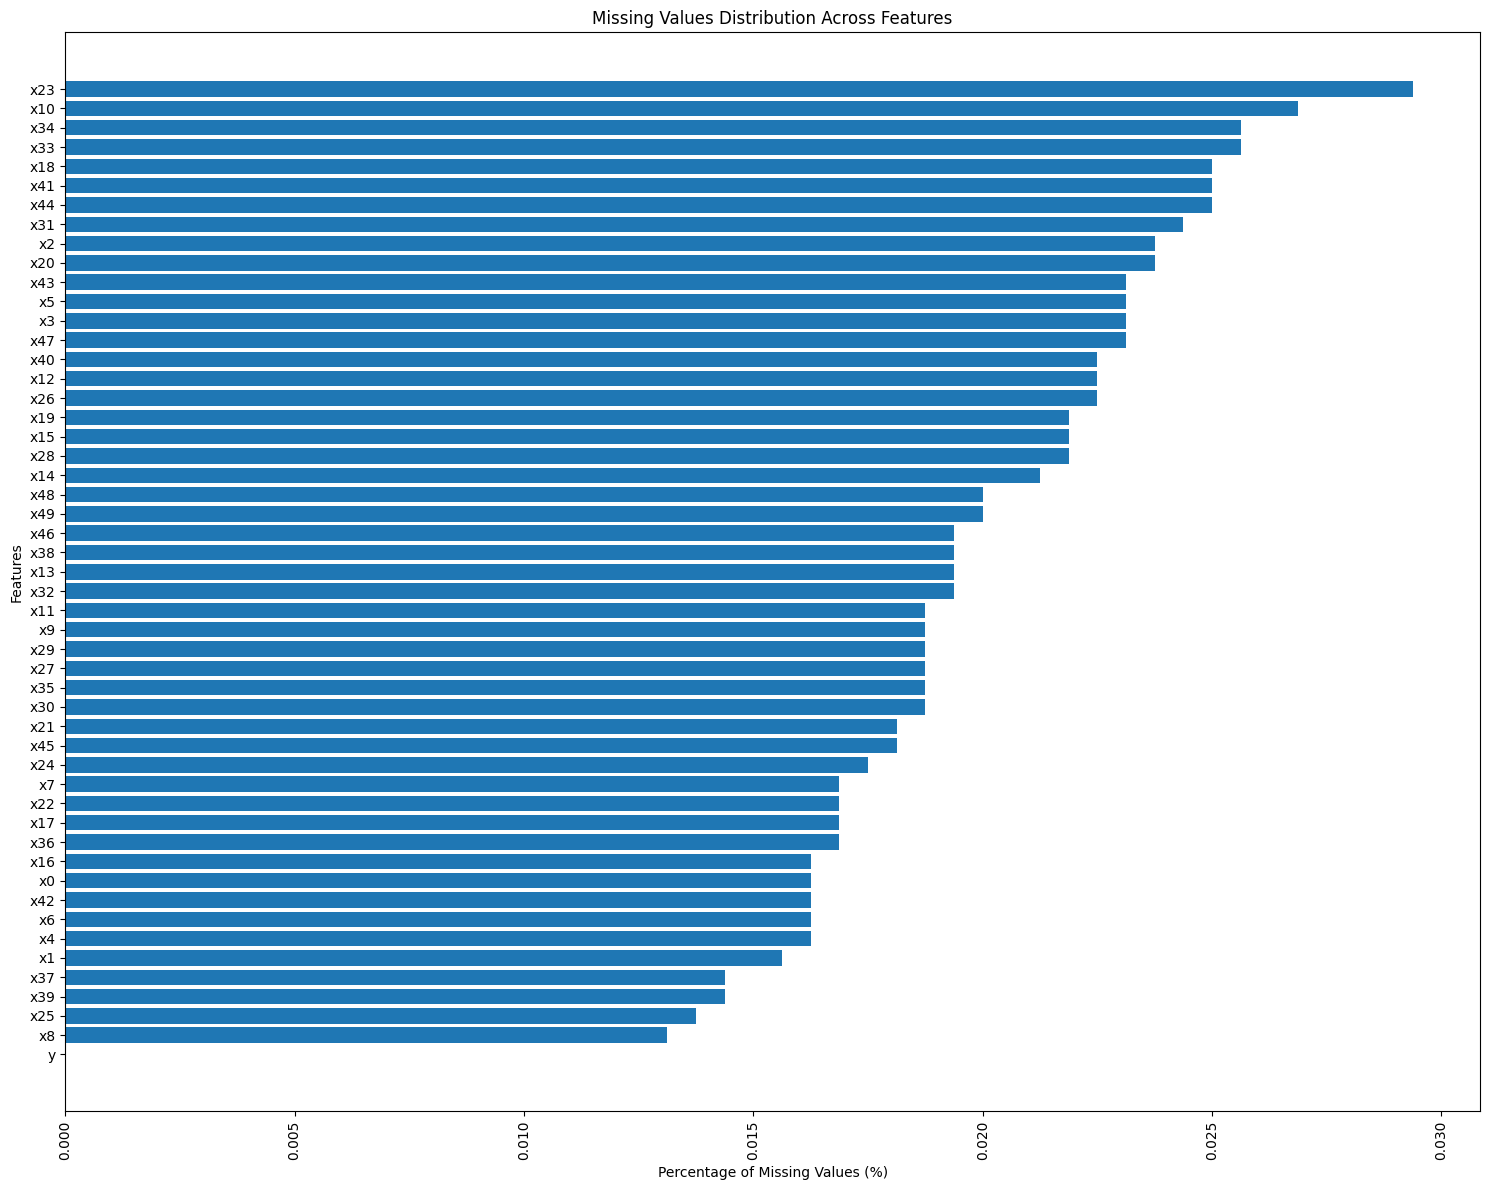

In [10]:
# Create the plot
plt.figure(figsize=(15, 12))
plt.barh(missing.index, missing.Percentage)
plt.xticks(rotation=90)
plt.title('Missing Values Distribution Across Features')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Features')
plt.tight_layout()
# Save the plot
plt.savefig('./report/plots/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

- There are many features having missing values
- The feature x23 has largest percentage of missing values at 0.03%
- The target variable **y** doesn't have missing values


### Imputation
- With the small amount of missing values, we can simply impute the numeric value with KNNImputer and the categorical value with most frequency.
- The categorical value having $ amount x37 could be converted to numeric before applying imputation
#### Impute numeric values

In [11]:
from sklearn.impute import KNNImputer
Kimputer = KNNImputer(n_neighbors=5, weights='uniform')

In [12]:
df.x37 = df.x37.replace('\$', '', regex=True).astype(float)

In [13]:
df_num = df.select_dtypes(include='number')


In [14]:
df_num_imputed = pd.DataFrame(Kimputer.fit_transform(df_num), columns=df_num.columns)
df_num_imputed.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x41,x42,x43,x44,x45,x46,x47,x48,x49,y
0,-0.166563,-3.961588,4.621113,2.481908,-1.800135,0.804684,6.718751,-14.789997,-1.040673,-4.204950,...,-1.497117,5.414063,-2.325655,1.674827,-0.264332,60.781427,-7.689696,0.151589,-8.040166,0.0
1,-0.149894,-0.585676,27.839856,4.152333,6.426802,-2.426943,40.477058,-6.725709,0.896421,0.330165,...,36.292790,4.490915,0.762561,6.526662,1.007927,15.805696,-4.896678,-0.320283,16.719974,0.0
2,-0.321707,-1.429819,12.251561,6.586874,-5.304647,-11.311090,17.812850,11.060572,5.325880,-2.632984,...,-0.368491,9.088864,-0.689886,-2.731118,0.754200,30.856417,-7.428573,-2.090804,-7.869421,0.0
3,-0.245594,5.076677,-24.149632,3.637307,6.505811,2.290224,-35.111751,-18.913592,-0.337041,-5.568076,...,15.691546,-7.467775,2.940789,-6.424112,0.419776,-72.424569,5.361375,1.806070,-7.670847,0.0
4,-0.273366,0.306326,-11.352593,1.676758,2.928441,-0.616824,-16.505817,27.532281,1.199715,-4.309105,...,-13.911297,-5.229937,1.783928,3.957801,-0.096988,-14.085435,-0.208351,-0.894942,15.724742,1.0


#### Impute categorical values
- Impute with None

In [15]:
df_cat = df.select_dtypes(include='object')
df_cat.head()

,x24,x29,x30,x32
0,euorpe,July,tuesday,0.0%
1,asia,Aug,wednesday,-0.02%
2,asia,July,wednesday,-0.01%
3,asia,July,wednesday,0.01%
4,asia,July,tuesday,0.01%


In [16]:
Cimputer = SimpleImputer(strategy='most_frequent')

In [17]:
df[['x24']] = Cimputer.fit_transform(df[['x24']])
df[['x29']] = Cimputer.fit_transform(df[['x29']])
df[['x32']] = Cimputer.fit_transform(df[['x32']])
df[['x30']] = Cimputer.fit_transform(df[['x30']])



### Distribution of Label values
- The bar plot shows that 60% are for label 1 and 40% are for label 0
- They are consider good enough distribution

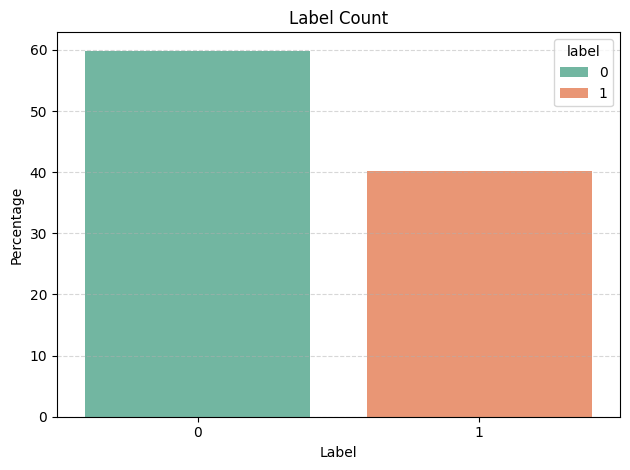

<Figure size 640x480 with 0 Axes>

In [18]:
# Convert value_counts to DataFrame
label_counts = df['y'].value_counts().reset_index()
label_counts.columns = ['label', 'count']
label_counts['percentage'] = (label_counts['count'] / label_counts['count'].sum()) * 100

# Plot using seaborn
sns.barplot(data=label_counts, x='label', y='percentage', hue='label', palette='Set2')
plt.title('Label Count')
plt.xlabel('Label')
plt.ylabel('Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.savefig('./report/plots/label_count.png', dpi=300, bbox_inches='tight')



### Distribution of 4 categorical data

In [19]:
def plot_categorical_grid(df, cat_cols,nrot, target_col='y', n_rows=2, n_cols=2):
    # Set up figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16,16))
    axes = axes.flatten()

    # Define color mapping
    expected_order = [1, 0]
    colors = sns.color_palette("Set2")
    #colors = {1: "red", 0: "blue"}

    for i, col in enumerate(cat_cols):
        ax = axes[i]
        
        # Build count DataFrame
        count_df = (
            df.groupby([col, target_col])
            .size()
            .reset_index(name='count')
            .pivot(index=col, columns=target_col, values='count')
            .fillna(0)
        )

        # Sort by total count descending
        count_df['total'] = count_df.sum(axis=1)
        count_df = count_df.sort_values(by='total', ascending=False).drop(columns='total')

        # Normalize to get proportions
        total_count = count_df.values.sum()
        prop_df = count_df / total_count * 100

        # Reorder columns to expected order
        available_order = [t for t in expected_order if t in prop_df.columns]
        prop_df = prop_df[available_order]

        # Plot
        prop_df.plot(
            kind='bar',
            stacked=True,
            ax=ax,
            color=[colors[c] for c in available_order],
            legend=False
        )

        ax.set_title(col)
        ax.set_ylabel("Proportion (%)")
        ax.set_xlabel("")
        ax.tick_params(axis='x', labelsize=15,rotation=nrot)
        ax.tick_params(axis='y', labelsize=15)

    # Shared legend
    axes[-1].legend(loc='upper right', fontsize='medium', frameon=True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('./report/plots/cat_grid.png', dpi=300, bbox_inches='tight')

    plt.show()


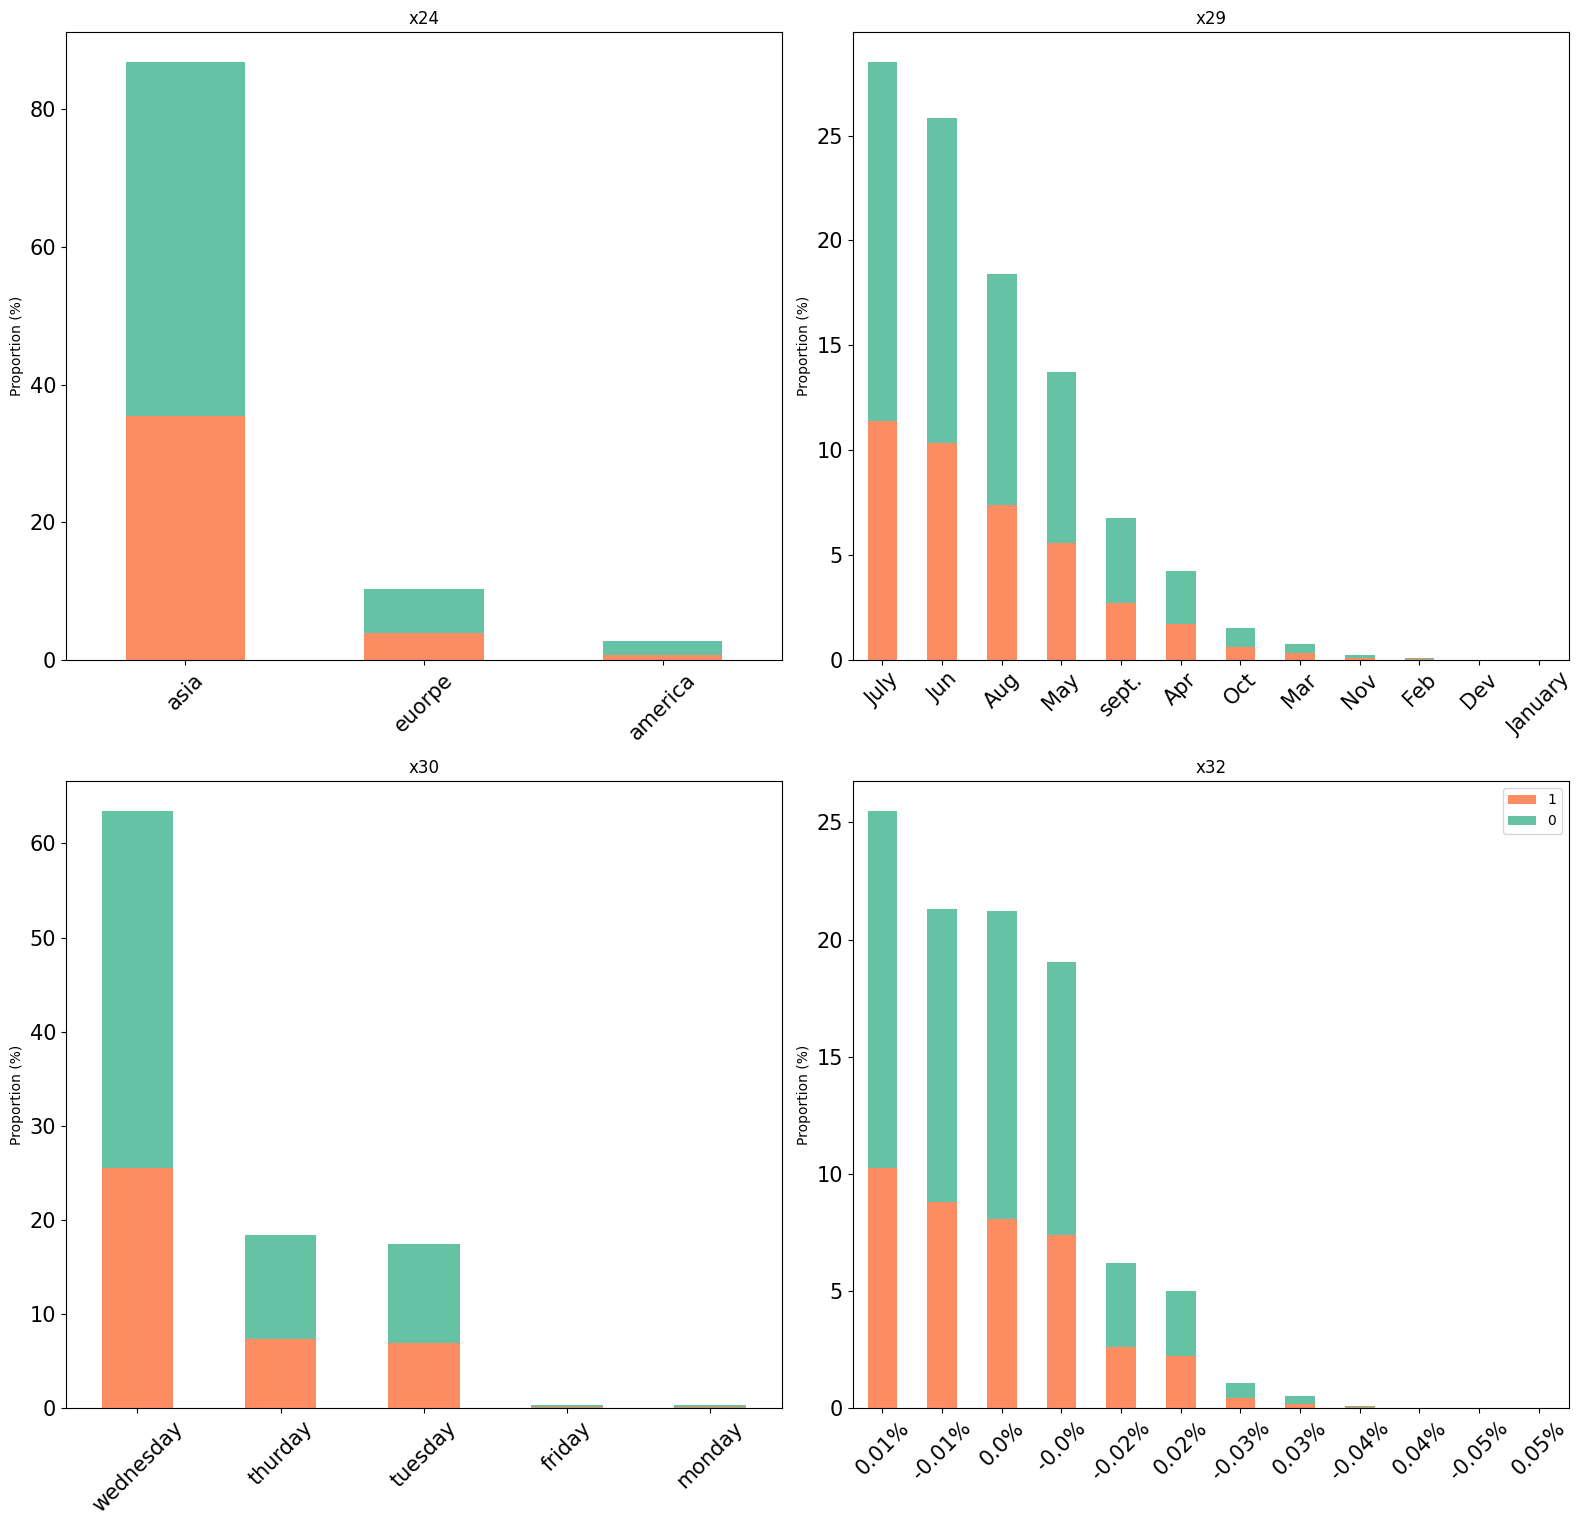

In [20]:
plot_categorical_grid(df, ['x24', 'x29', 'x30', 'x32'],45)

- **x24**: 85% incident occured in Asia while only 10% in Europe and 5% in America. No other continent found.
- **x29**: Summer (June, July, August) have most of the incidents occured with the summation of more than 75%
- **x30**: Most incidents occured during weekday with the highest one on Wednesday. No incident occured on weekend and the Monday/Friday have very low attendence
- The percentage in **x32** show minor changes with 90% changes are from the range of 0.0% to 0.01%
- We can infer that this is the cross continent summer holiday travel data

To use this categorical data, we need to apply One Hot Encoding to it:

In [21]:
df_cat_ohe = pd.get_dummies(df[['x24', 'x29', 'x30', 'x32']],drop_first=False,dtype=int)


### Cross Correlation Analysis

- Calculate the cross correlation between 46 numeric features
- Sort list the strong correlation pairs with R>0.8


In [22]:
X = df_num_imputed.drop(columns=['y'])

### VIF


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add constant (intercept) for VIF calculation
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]


In [24]:
cnew = vif_data[vif_data['VIF']>10]
cnew

,Feature,VIF
2,x2,34126.355432
6,x6,34057.358852
7,x7,12478.838091
12,x12,3195.499162
20,x20,1897.794550
23,x23,2244.924924
26,x27,3896.319704
27,x28,1167.484493
33,x37,102.599354
34,x38,18737.463814


In [25]:
X_new = X[cnew['Feature']]

In [26]:
corr = X_new.corr(method="pearson")

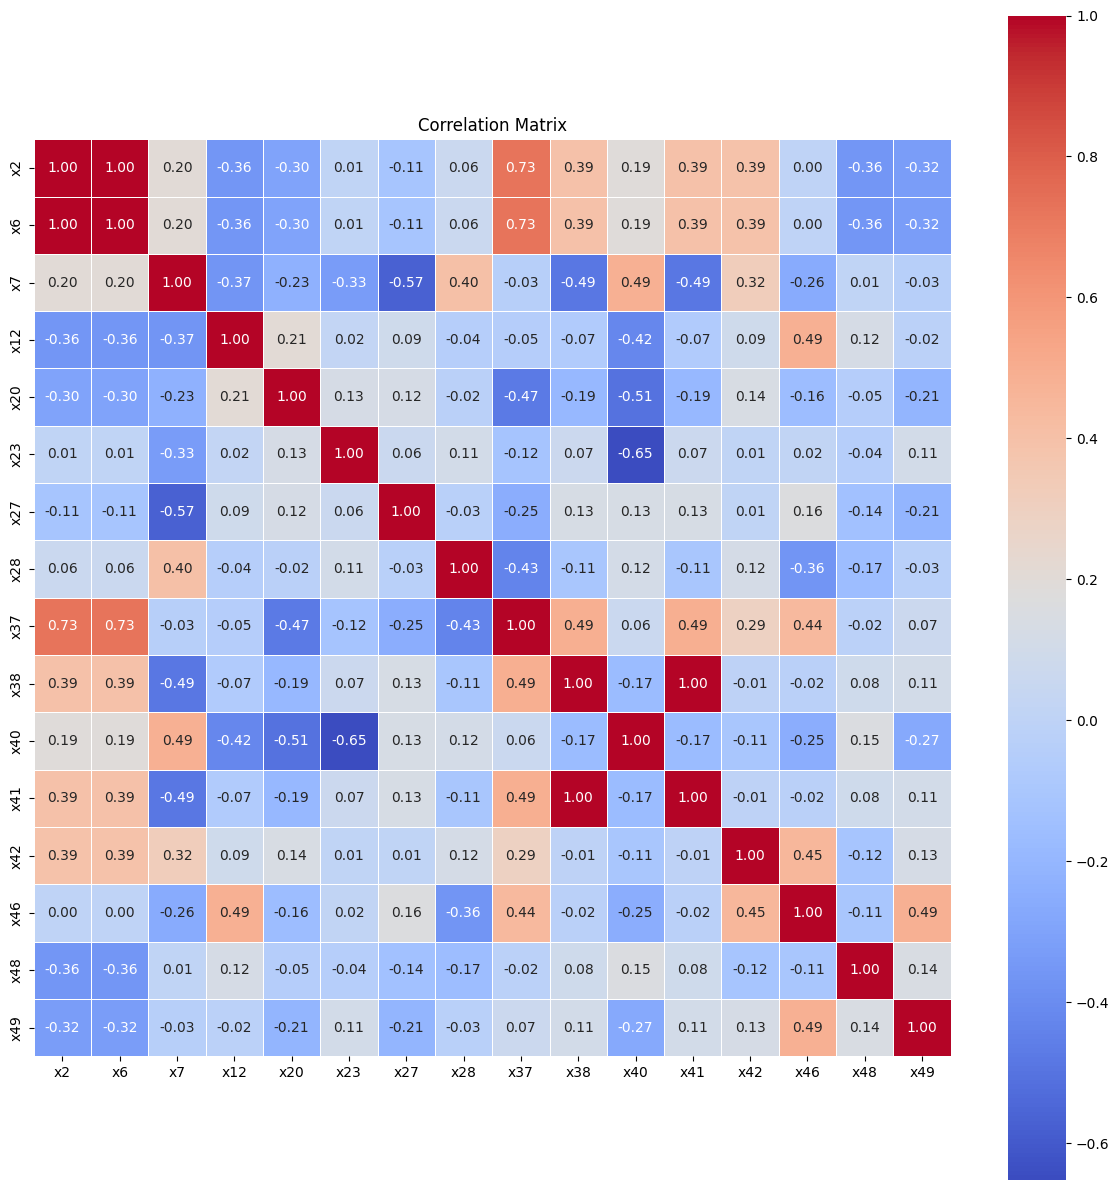

In [27]:
plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig('./report/plots/heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

- Out of 46 numeric features only 4 pairs have high enough correlation more than 0.7
- There may exists some collinearity between the pair of (x2, x6) and (x38, x41)
- High VIF features did not exhibit high cross correlation, except pair (x2,x6) and (x38,x41)
- We will remove x6 and x41 for the calculation

In [28]:
X_num = X.drop(columns=['x6', 'x41'])

### Distribution of numerical features

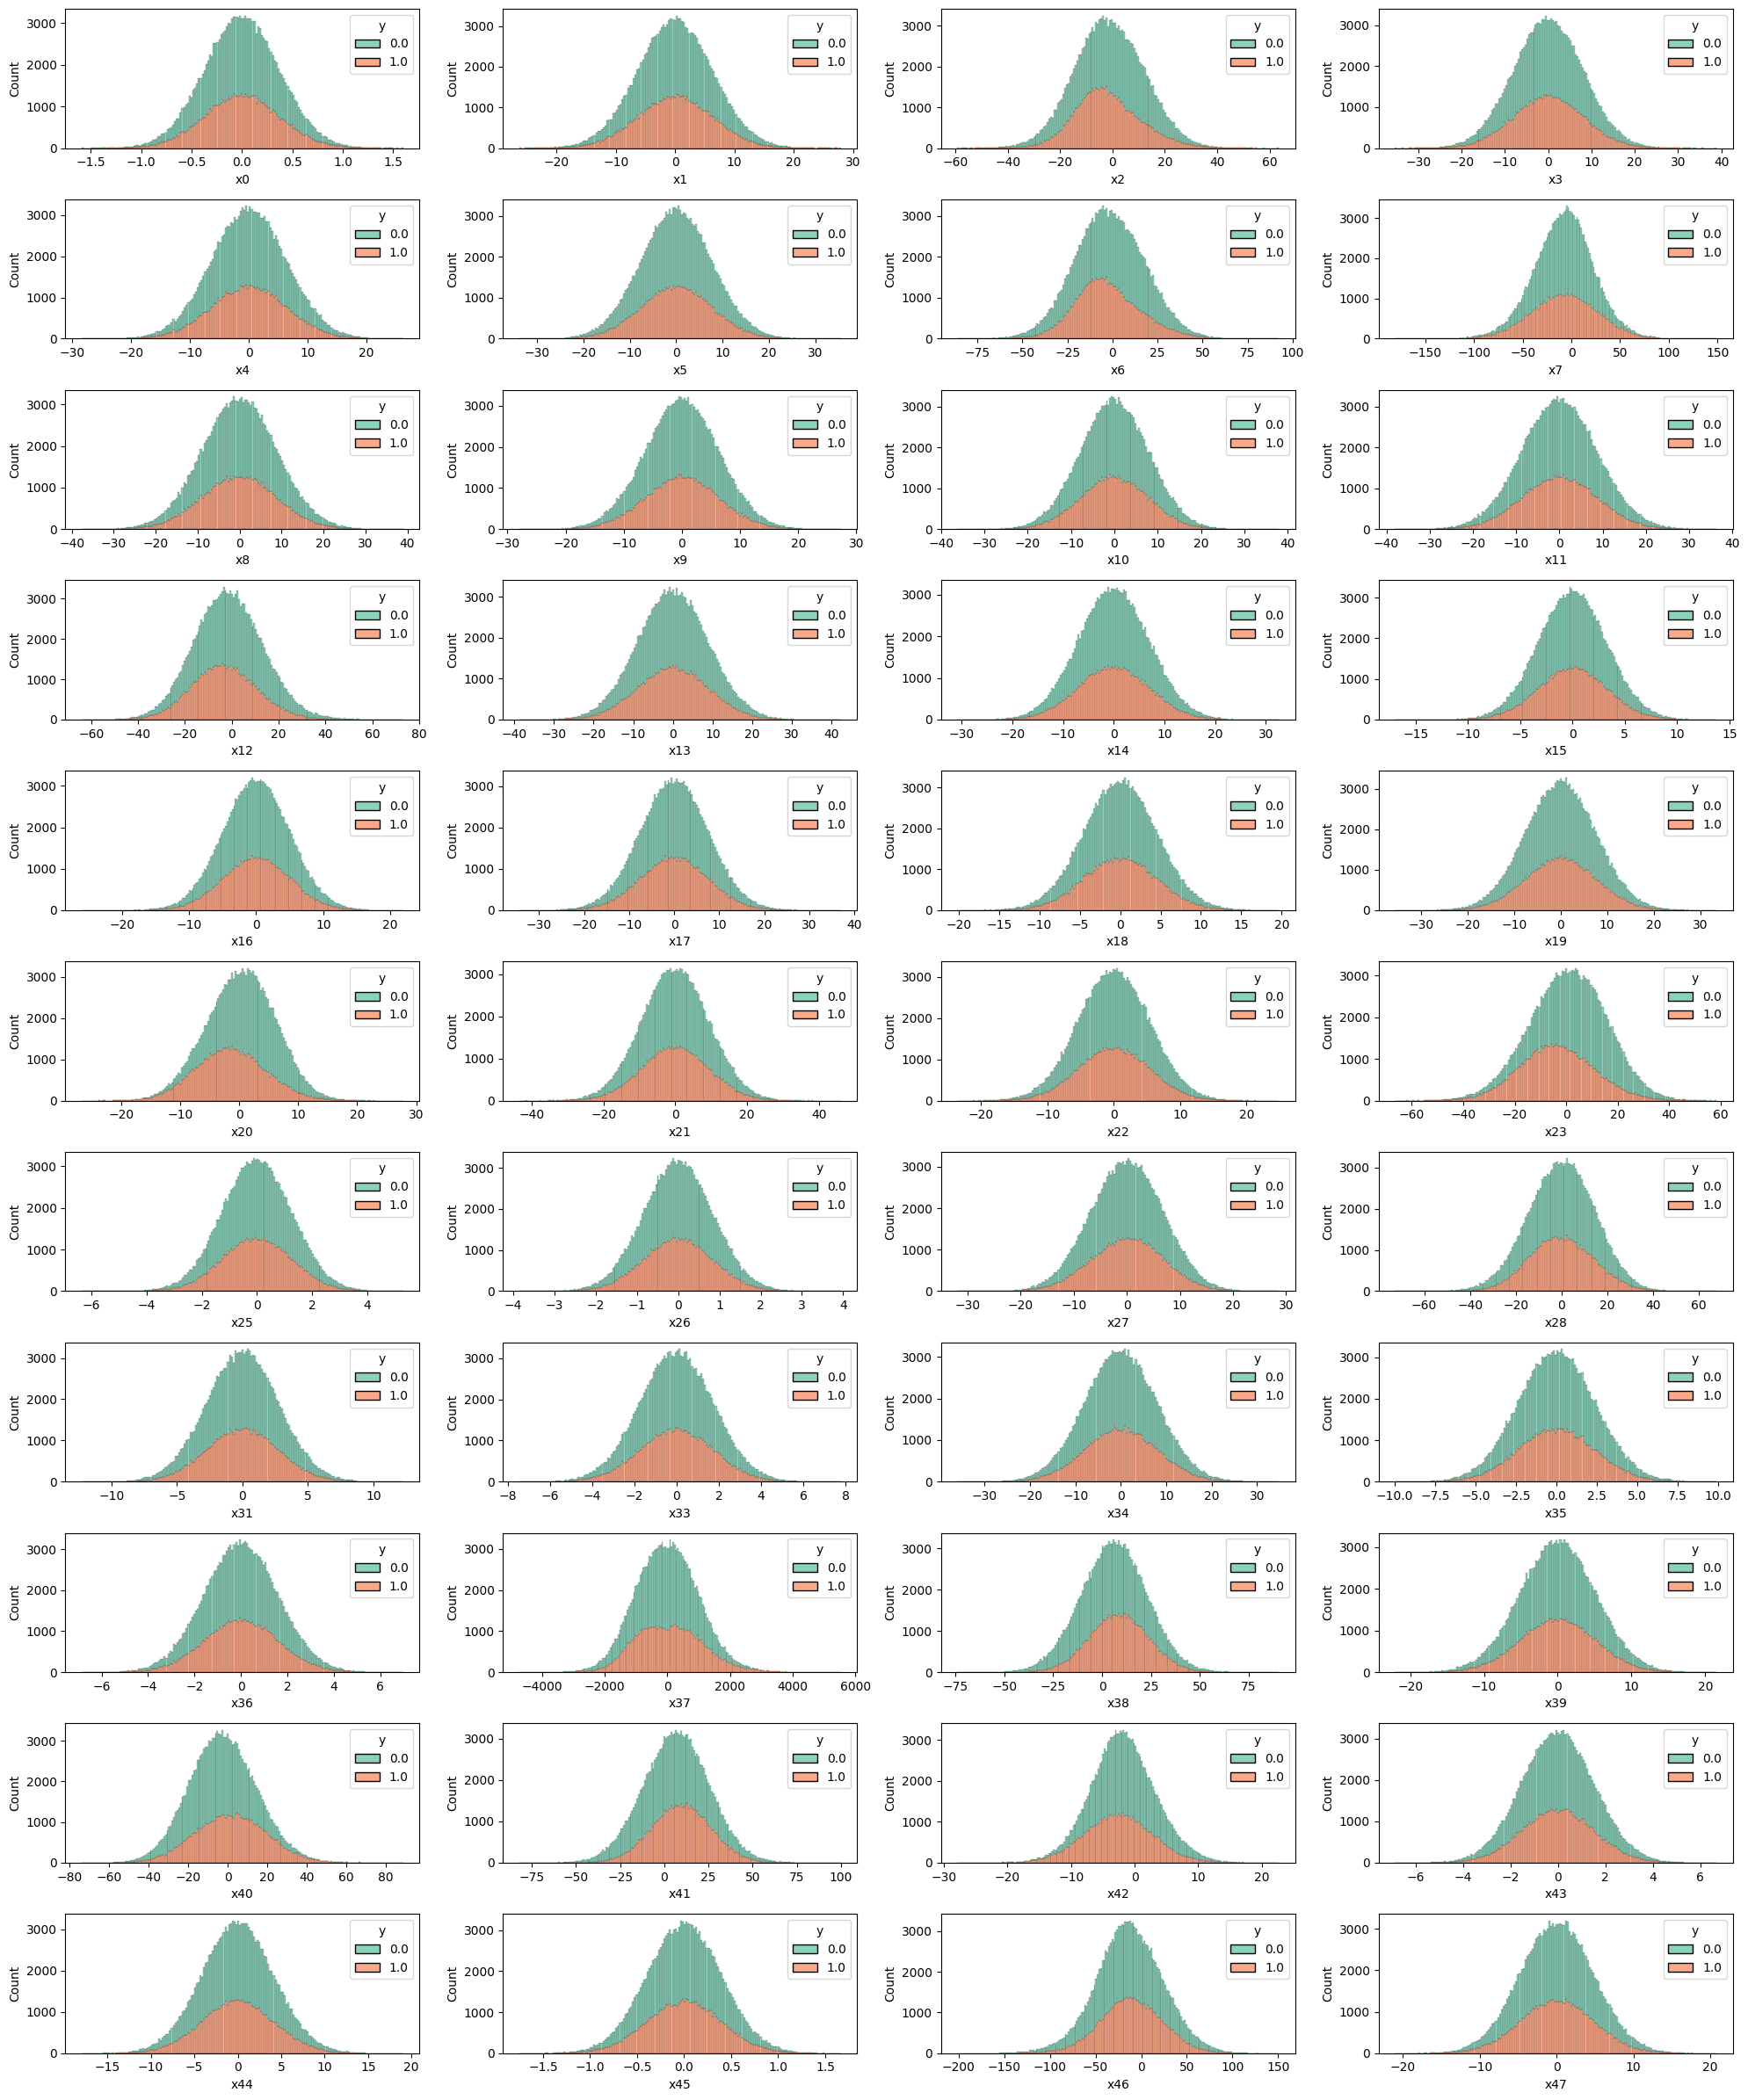

In [29]:
# Create subplots
fig, axes = plt.subplots(11, 4, figsize=(20, 24))
axes = axes.flatten()
palette = sns.color_palette("Set2", 44)

# Plot each histogram in a subplot
for i, column in enumerate(df_num_imputed.columns):
    if i==44: 
        break
    sns.histplot(data = df_num_imputed,
                x=column,
                palette='Set2',
                ax=axes[i],
                hue='y',
                multiple='stack',
                legend=True)
plt.tight_layout()
plt.savefig('./report/plots/hist_num.png', dpi=300, bbox_inches='tight')
plt.show()


- Histogram plots show all numeric input features having Gaussian distribution with bell shape.
- The scale are different thought but if we are using tree-based model, there is no need to scale it

In [30]:
X = pd.merge(X_num, df_cat_ohe,left_index=True, right_index=True)

In [31]:
X.head()

,x0,x1,x2,x3,x4,x5,x7,x8,x9,x10,...,x32_-0.02%,x32_-0.03%,x32_-0.04%,x32_-0.05%,x32_0.0%,x32_0.01%,x32_0.02%,x32_0.03%,x32_0.04%,x32_0.05%
0,-0.166563,-3.961588,4.621113,2.481908,-1.800135,0.804684,-14.789997,-1.040673,-4.204950,6.187465,...,0,0,0,0,1,0,0,0,0,0
1,-0.149894,-0.585676,27.839856,4.152333,6.426802,-2.426943,-6.725709,0.896421,0.330165,-11.708859,...,1,0,0,0,0,0,0,0,0,0
2,-0.321707,-1.429819,12.251561,6.586874,-5.304647,-11.311090,11.060572,5.325880,-2.632984,1.572647,...,0,0,0,0,0,0,0,0,0,0
3,-0.245594,5.076677,-24.149632,3.637307,6.505811,2.290224,-18.913592,-0.337041,-5.568076,-2.000255,...,0,0,0,0,0,1,0,0,0,0
4,-0.273366,0.306326,-11.352593,1.676758,2.928441,-0.616824,27.532281,1.199715,-4.309105,6.667530,...,0,0,0,0,0,1,0,0,0,0


In [32]:
y = df.y

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=123)

### XGBoost model - All data
- Setup parameters for Cross Validation

In [34]:
params = {
    'subsample': 0.75,
    'learning_rate':0.1,
    'max_depth': 50,
    'eval_metric': 'auc',
    'objective': 'binary:logistic',
    'device':'cuda'
}

In [71]:
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': 0.1,
    'max_depth': 20,
    'subsample': 0.8,
    'device': 'cuda'
}

In [72]:
traindata = xgb.DMatrix(X_train, label=y_train)
testdata = xgb.DMatrix(X_test, label=y_test)

In [73]:
%%time
model_xgb = xgb.train(params,
              evals=[(traindata,'train'),(testdata,'test')],
              num_boost_round=100,
              dtrain=traindata,
              early_stopping_rounds=5)

[0]	train-logloss:0.60271	test-logloss:0.61381
[1]	train-logloss:0.54312	test-logloss:0.56490
[2]	train-logloss:0.49141	test-logloss:0.52297
[3]	train-logloss:0.44740	test-logloss:0.48725
[4]	train-logloss:0.40900	test-logloss:0.45626
[5]	train-logloss:0.37453	test-logloss:0.42873
[6]	train-logloss:0.34456	test-logloss:0.40555
[7]	train-logloss:0.31769	test-logloss:0.38487
[8]	train-logloss:0.29371	test-logloss:0.36614
[9]	train-logloss:0.27261	test-logloss:0.34982
[10]	train-logloss:0.25283	test-logloss:0.33419
[11]	train-logloss:0.23483	test-logloss:0.31980
[12]	train-logloss:0.21875	test-logloss:0.30752
[13]	train-logloss:0.20414	test-logloss:0.29634
[14]	train-logloss:0.19087	test-logloss:0.28599
[15]	train-logloss:0.17873	test-logloss:0.27664
[16]	train-logloss:0.16783	test-logloss:0.26843
[17]	train-logloss:0.15795	test-logloss:0.26059
[18]	train-logloss:0.14864	test-logloss:0.25350
[19]	train-logloss:0.14000	test-logloss:0.24672
[20]	train-logloss:0.13220	test-logloss:0.24072
[2

#### Cross Validation

In [74]:
%%time
xgbcv = xgb.cv(params,
              dtrain=traindata,
              nfold=10,
              stratified=False,
              metrics='auc',
              num_boost_round=100,
              verbose_eval=True,
              early_stopping_rounds=5)

[0]	train-auc:0.96802+0.00028	test-auc:0.91659+0.00324
[1]	train-auc:0.98624+0.00084	test-auc:0.94097+0.00270
[2]	train-auc:0.99175+0.00065	test-auc:0.95120+0.00273
[3]	train-auc:0.99427+0.00030	test-auc:0.95670+0.00231
[4]	train-auc:0.99562+0.00023	test-auc:0.96017+0.00213
[5]	train-auc:0.99647+0.00018	test-auc:0.96245+0.00200
[6]	train-auc:0.99708+0.00016	test-auc:0.96413+0.00184
[7]	train-auc:0.99753+0.00013	test-auc:0.96566+0.00172
[8]	train-auc:0.99794+0.00008	test-auc:0.96705+0.00169
[9]	train-auc:0.99825+0.00007	test-auc:0.96805+0.00159
[10]	train-auc:0.99849+0.00005	test-auc:0.96900+0.00140
[11]	train-auc:0.99869+0.00005	test-auc:0.96977+0.00144
[12]	train-auc:0.99888+0.00004	test-auc:0.97051+0.00137
[13]	train-auc:0.99903+0.00004	test-auc:0.97115+0.00139
[14]	train-auc:0.99916+0.00004	test-auc:0.97181+0.00142
[15]	train-auc:0.99926+0.00003	test-auc:0.97228+0.00142
[16]	train-auc:0.99936+0.00003	test-auc:0.97280+0.00139
[17]	train-auc:0.99944+0.00002	test-auc:0.97327+0.00145
[1

In [75]:
xgbcv

,train-auc-mean,train-auc-std,test-auc-mean,test-auc-std
0,0.968021,2.808801e-04,0.916588,0.003237
1,0.986238,8.363649e-04,0.940968,0.002696
2,0.991755,6.471200e-04,0.951200,0.002731
3,0.994274,3.020093e-04,0.956697,0.002310
4,0.995618,2.343884e-04,0.960166,0.002130
...,...,...,...,...
95,1.000000,2.991286e-09,0.983453,0.000813
96,1.000000,2.733527e-09,0.983465,0.000811
97,1.000000,2.571804e-09,0.983481,0.000808
98,1.000000,1.716158e-09,0.983480,0.000818


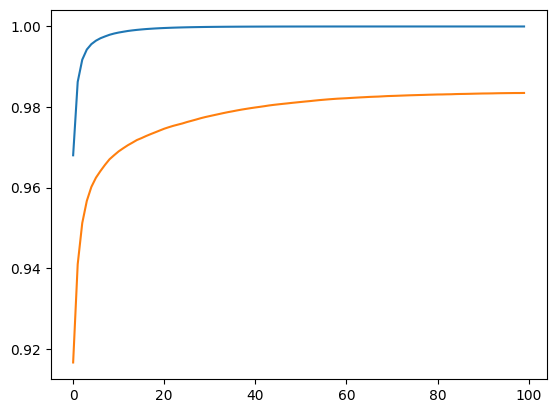

In [76]:
plt.plot(xgbcv['train-auc-mean'])
plt.plot(xgbcv['test-auc-mean'])

plt.savefig('./report/plots/xgbcv.png', dpi=300, bbox_inches='tight')


In [77]:
# Make predictions
predictions = model_xgb.predict(testdata)
y_pred = (predictions > 0.5).astype(int)


In [78]:

print(classification_report(np.array(y_test),y_pred))



              precision    recall  f1-score   support

           0       0.95      0.96      0.95     19218
           1       0.94      0.92      0.93     12782

    accuracy                           0.94     32000
   macro avg       0.94      0.94      0.94     32000
weighted avg       0.94      0.94      0.94     32000



In [79]:
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[18428   790]
 [ 1044 11738]]
0.9426875


In [80]:
from sklearn.metrics import ConfusionMatrixDisplay

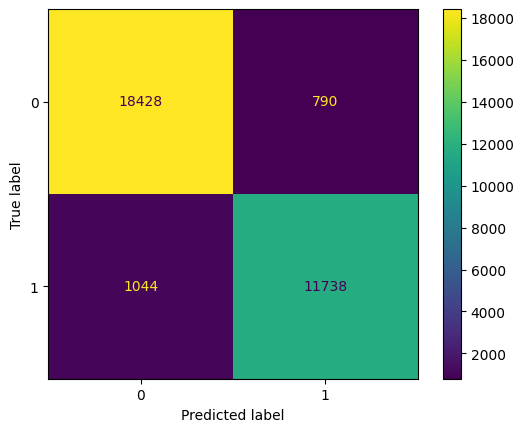

In [81]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.savefig('./report/plots/CM.png', dpi=300, bbox_inches='tight')
